In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum

In [3]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [4]:
mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

In [5]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1', luminosityType='SDSS', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
Progress: 3367/3367g Galaxy Group ID 3732 / 3732
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5


Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
Progress: 2664/2664g Galaxy Group ID 3006 / 3006
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
Progress: 2361/2361g Galaxy Group ID 2664 / 2664
Loaded 2361 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p4/data/galaxy_data_TNG300-1_.hdf5
Progress: 2054/2054g Galaxy Group ID 2361 / 2361
Loaded 2054 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p5/data/galaxy_data_TNG300-1_.hdf5
Progress: 1531/1531g Galaxy Group ID 2054 / 2054
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
Progress: 900/900ing Galaxy Group ID 1531 / 1531
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from 

In [7]:
#print num of clusters and satellites in each snapshot and mass bin:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup


for snapshotEnum in allSnapshotEnums:
    snapshot = snapshotEnum[0]
    print(f"Snapshot: {snapshot}")
    galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
    mass_bins : list[ListGalaxyGroup] = [
        galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysis.filtered_gt15_list_of_galaxy_groups,
    ]
    for mass_bin, mass_bin_label in zip(mass_bins, mass_bin_labels):
        num_clusters = len(mass_bin.getAllGalaxyGroups())
        num_satellites = sum([len(galaxy_group.getSatelliteSubhalos()) for galaxy_group in mass_bin.getAllGalaxyGroups()])
        print(f" Mass bin: {mass_bin_label}, Num clusters: {num_clusters}, Num satellites: {num_satellites}")

Snapshot: 99
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2586, Num satellites: 20784
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 866, Num satellites: 20908
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 239, Num satellites: 16157
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 38, Num satellites: 7271
 Mass bin: $M_{200}>1e15$, Num clusters: 3, Num satellites: 1483
Snapshot: 91
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2366, Num satellites: 22629
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 780, Num satellites: 21745
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 192, Num satellites: 15591
 Mass bin: $1e14.5<M_{200}<1e15$, Num clusters: 26, Num satellites: 5609
 Mass bin: $M_{200}>1e15$, Num clusters: 2, Num satellites: 1057
Snapshot: 84
 Mass bin: $1e13<M_{200}<1e13.5$, Num clusters: 2152, Num satellites: 23844
 Mass bin: $1e13.5<M_{200}<1e14$, Num clusters: 680, Num satellites: 21518
 Mass bin: $1e14<M_{200}<1e14.5$, Num clusters: 150, Num satellites: 13341
 Mass b

In [ ]:
#check in snapshot 0, that all galaxies in the gt13 ls13p5 mass bin have M200 between 1e13 and 1e13.5:
snapshotEnum = SnapshotEnum.SNAPSHOT_99
snapshot = snapshotEnum.value[0]
print(f"Snapshot: {snapshot}")
galaxyAnalysis = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot)
mass_bin = galaxyAnalysis.filtered_gt13_ls13p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 1e13 and M200 < 10**13.5, f"Galaxy group with M200={M200:.2e} is not in the gt13 ls13p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt13p5_ls14_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**13.5 and M200 < 10**14, f"Galaxy group with M200={M200:.2e} is not in the gt13p5 ls14 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14_ls14p5_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14 and M200 < 10**14.5, f"Galaxy group with M200={M200:.2e} is not in the gt14 ls14p5 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt14p5_ls15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**14.5 and M200 < 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt14p5 ls15 mass bin!"
    
mass_bin = galaxyAnalysis.filtered_gt15_list_of_galaxy_groups
for galaxy_group in mass_bin.getAllGalaxyGroups():
    M200 = galaxy_group.getMCrit200()
    assert M200 > 10**15, f"Galaxy group with M200={M200:.2e} is not in the gt15 mass bin!"

In [ ]:
print(listRedshiftGalaxyAnalysis.getAllLoadedSnapshots())
print(SnapshotEnum.SNAPSHOT_99.value[0])
galaxyAnalysisZ0 = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(SnapshotEnum.SNAPSHOT_99.value[0])

[99, 91, 84, 78, 72, 67, 59, 50]
99


In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

# check snaphot compared to z=0

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [6]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_SDSS_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p1, TNG300-1
Total Galaxy Groups to process: 220 with pairs : 1647602
Processing Subhalo 102/102 in Galaxy Group ID 99 with total pairs 51513COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 26/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_SDSS_tng300z0_TNG300-1
Processing snapshot 84...


Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
Processing snapshot 91...xy Group ID 3732 / 3732
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
Progres

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 112/112 in Galaxy Group ID 99 with total pairs 62160Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_tng300z0.1_default_luminosity_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
Progress: 3006/3006g Galaxy Group ID 3006 / 3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 96/96 in Galaxy Group ID 99 with total pairs 4560786Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/pairwise_polar_difference_tng300z0.2_vs_tng300z0.2_default_luminosity_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
Progress: 2664/2664g Galaxy Group ID 2664 / 2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Gro

...

Processing Subhalo 328/328 in Galaxy Group ID 9 with total pairs 536288Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/pairwise_polar_difference_tng300z0.5_vs_tng300z0.5_default_luminosity_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
Progress: 1531/1531g Galaxy Group ID 1531 / 1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 249/249 in Galaxy Group ID 9 with total pairs 308765Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/pairwise_polar_difference_tng300z0.7_vs_tng300z0.7_default_luminosity_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
Progress: 900/900ing Galaxy Group ID 900 / 900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total 

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 132/132 in Galaxy Group ID 8 with total pairs 864658Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/pairwise_polar_difference_tng300z1.0_vs_tng300z1.0_default_luminosity_TNG300-1


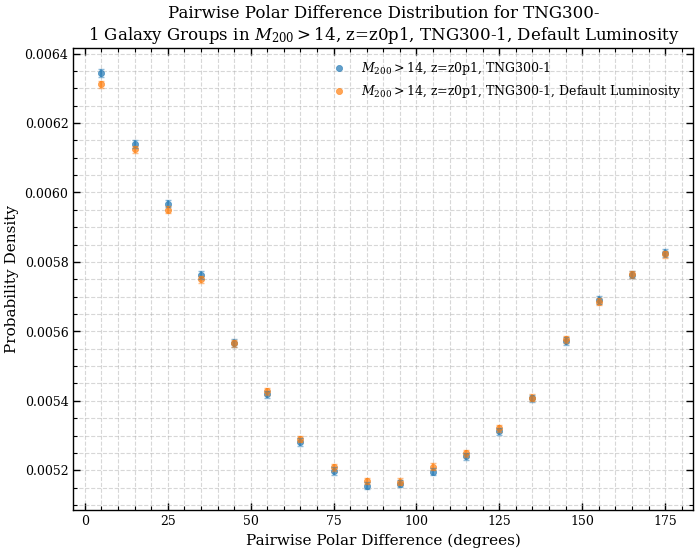

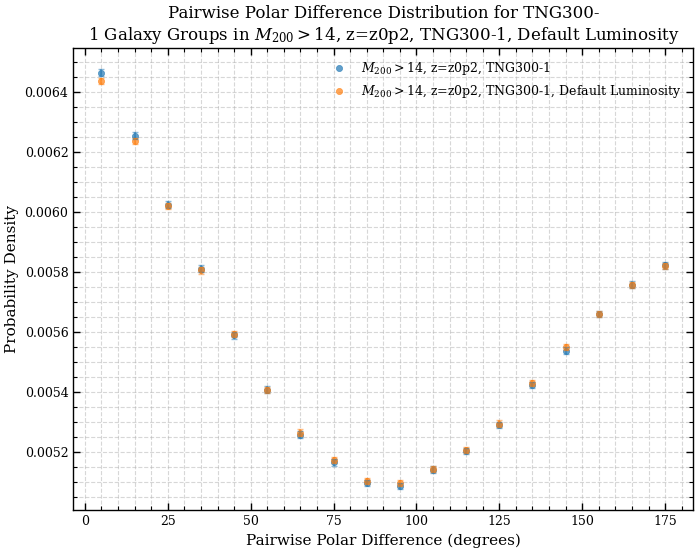

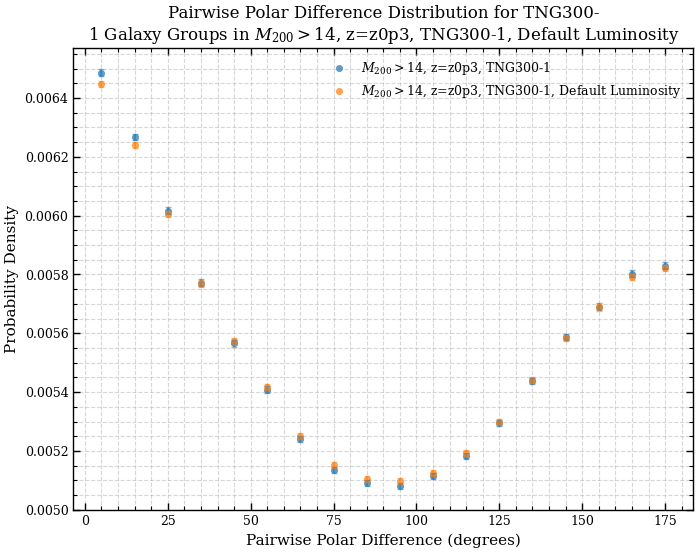

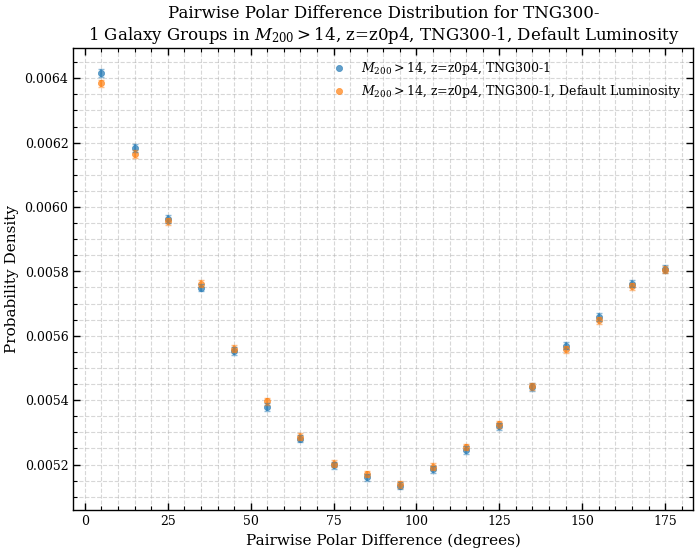

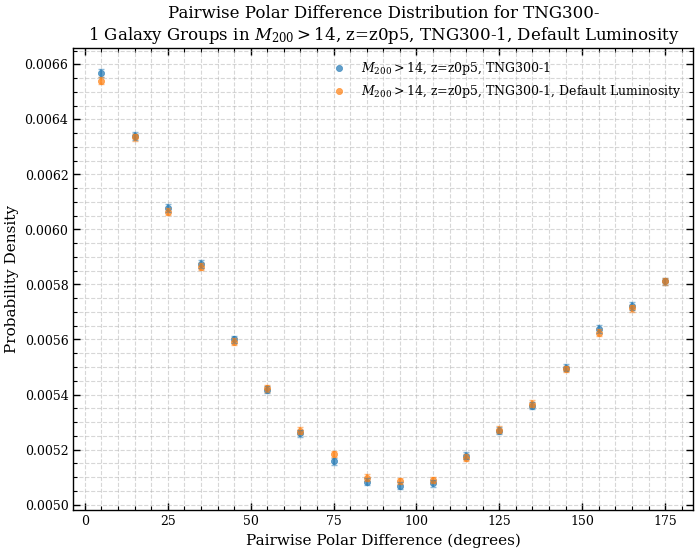

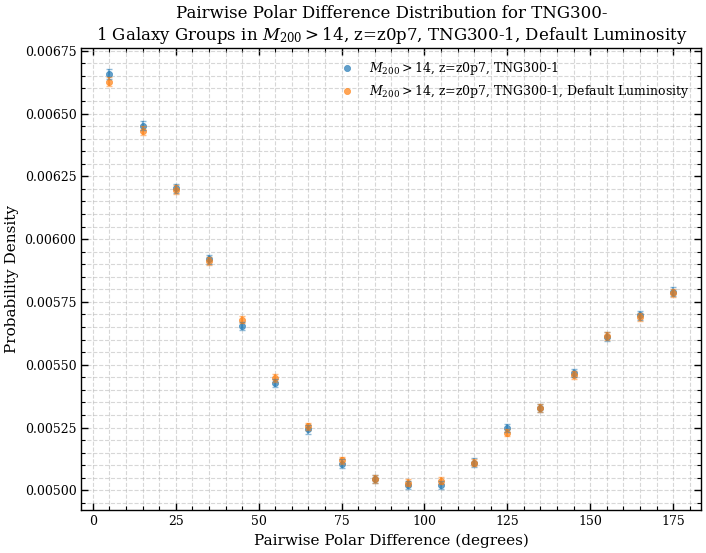

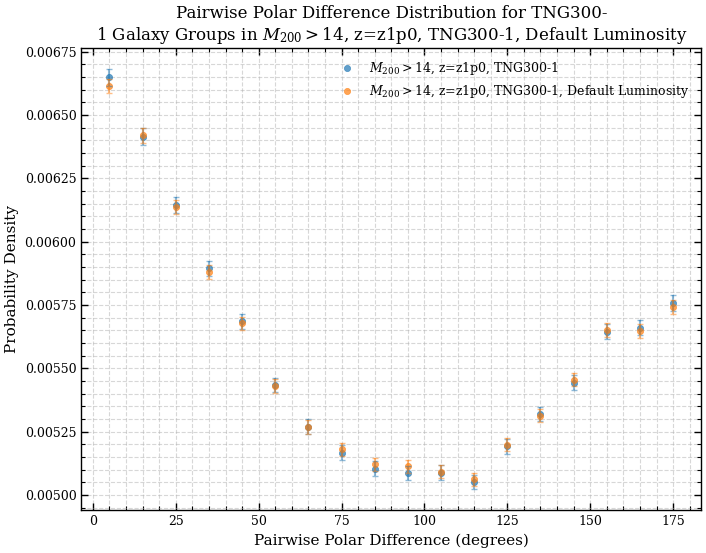

In [5]:
galaxyAnalysisZ0TNG300Default = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='Default')
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0TNG300Default.setSnapshot(snapshot[0], luminosityType='Default')

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300Default.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0TNG300Default.snapshot_dic[snapshot[0]][1]}, TNG300-1, Default Luminosity'))
    

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_default_luminosity_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
final: [np.float64(0.06727626743690919), np.float64(0.08305598729203958), np.float64(0.039708743219627335)]
lenMRL: 660, lenrandom: (220, 3000)tribution for Galaxy Group 220 / 220 with 103 satellites
99th percentile MRL: 0.25809800675607114
Overall number of MRL values above 99th percentile: 79 out of 660
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477843)]


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2851969435172817
Overall number of MRL values above 99th percentile: 81 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/mrl_difference_tng300z0.1_vs_tng300z0_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
final: [np.float64(0.06578292667682392), np.float64(0.15416648641861602), np.float64(0.14169104270824098)]
lenMRL: 522, lenrandom: (174, 3000)tribution for Galaxy Group 174 / 174 with 92 satel

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28589199124443027
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/mrl_difference_tng300z0.2_vs_tng300z0_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
final: [np.float64(0.11210911223030663), np.float64(0.09161774232657646), np.float64(0.09437307886899875)]
lenMRL: 393, lenrandom: (131, 3000)tribution for Galaxy Group 131 / 131 with 73 sate

...

lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28536515794304385
Overall number of MRL values above 99th percentile: 80 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/mrl_difference_tng300z0.5_vs_tng300z0_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
final: [np.float64(0.16542763499370366), np.float64(0.1966326119423784), np.float64(0.14821200239290197)]
lenMRL: 102, lenrandom: (34, 3000)stribution for Galaxy Group 34 / 34 with 231 satell

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2859511999748071
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/mrl_difference_tng300z0.7_vs_tng300z0_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
final: [np.float64(0.2210880946877993), np.float64(0.19496764891902507), np.float64(0.09695619315734465)]
lenMRL: 30, lenrandom: (10, 3000)istribution for Galaxy Group 10 / 10 with 121 satellites
99th percent

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2845650168701842
Overall number of MRL values above 99th percentile: 82 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/mrl_difference_tng300z1.0_vs_tng300z0_TNG300-1


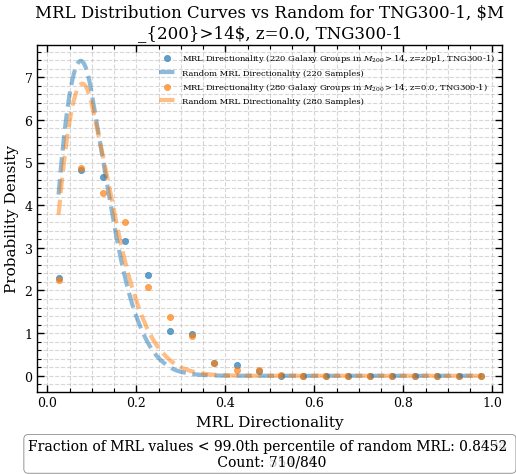

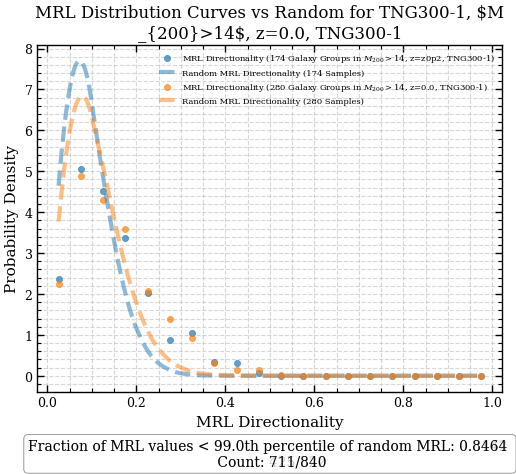

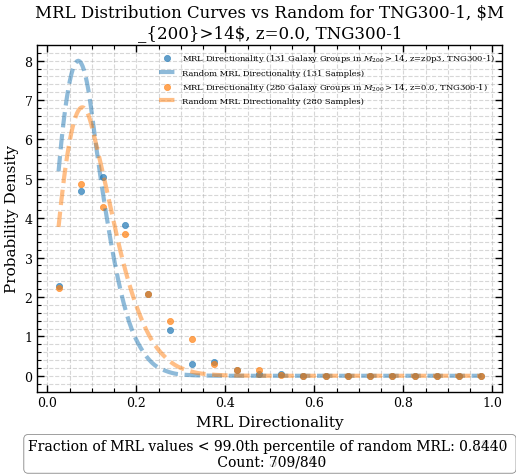

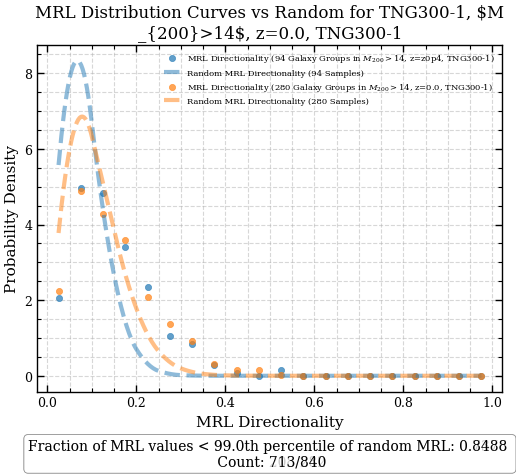

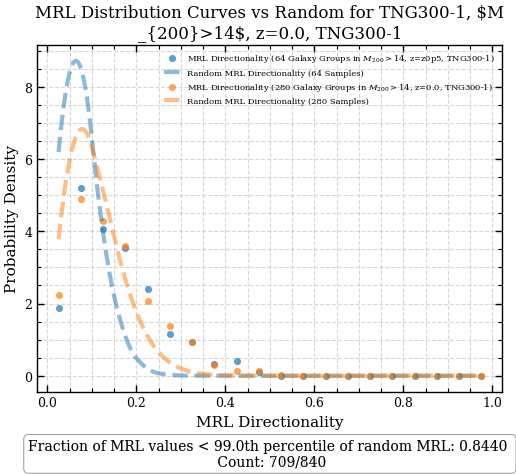

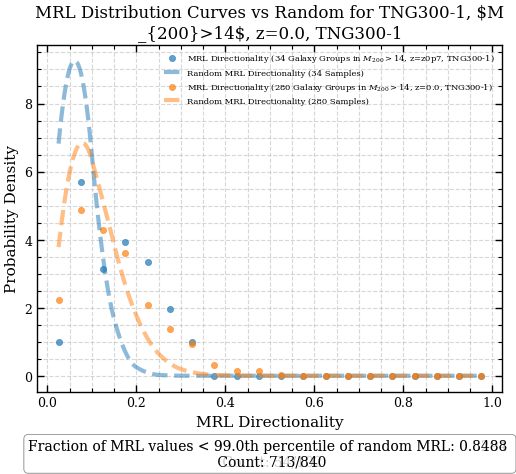

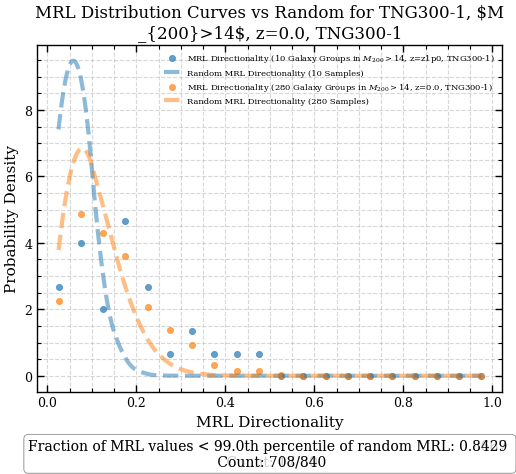

In [14]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] != 91: #already processed these snapshots
    #     continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")

    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []

    listRedshiftGG.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    listRedshiftGG.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))


    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlayMRLAndMRLRandom(listGG=listRedshiftGG,oneaxis=True, savefig=False)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right', fontsize=6)  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/mrl_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

In [8]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    redshifts.append(snapshot[1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90, _), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8512 (715/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.7500 (630/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477845)]
Fraction of MRL values below the 90th percentile of random MRL values: 0.6821 (573/840)tess
Processing snapshot 91...
final: [np.float64(0.06727626743690919), np.float64(0.0830559872920396), np.float64(0.039708743219627335)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8348 (551/660)ites
final: [np.float64(0.06727626743690919), np.float64(0.0830559872920396), np.float64(0.039708743219627335)]
Fraction of MRL values below the 95th percent

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_TNG300-1


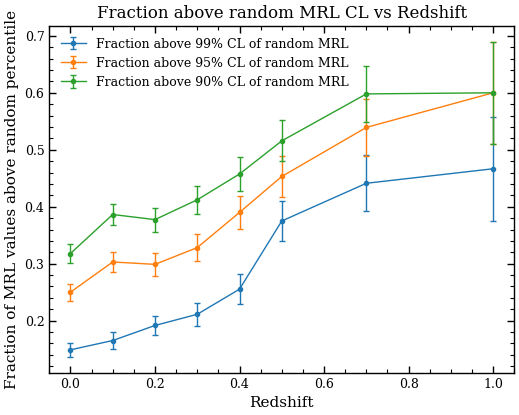

In [9]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow99),
    yerr=errBelow99,
    label='Fraction above 99% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow95),
    yerr=errBelow95,
    label='Fraction above 95% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow90),
    yerr=errBelow90,
    label='Fraction above 90% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction of MRL values above random percentile')
MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [10]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(snapshot[1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=1000
        )

        (f99, c99, n99,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90,_), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.9568 (7423/7758)tes
Fraction of MRL values below the 95th percentile of random MRL values: 0.8986 (6971/7758)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8408 (6523/7758)
Fraction of MRL values below the 99th percentile of random MRL values: 0.9496 (2467/2598)s
Fraction of MRL values below the 95th percentile of random MRL values: 0.8722 (2266/2598)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8079 (2099/2598)
Fraction of MRL values below the 99th percentile of random MRL values: 0.8717 (625/717)tess
Fraction of MRL values below the 95th percentile of random MRL values: 0.7796 (559/717)
Fraction of MRL values below the 90th percentile of random MRL values: 0.7127 (511/717)
Fraction of MRL values below the 99th percentile of random MRL values: 0.7105 (81/114)tes
Fraction of MRL values below the 95th percentile of random MRL values: 0

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_TNG300-1


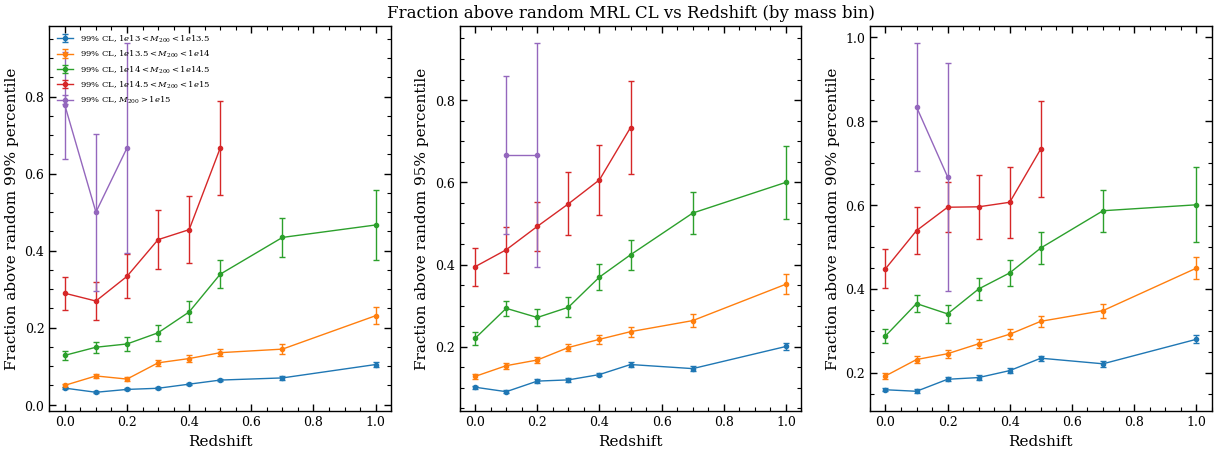

In [11]:
mass_bin_MRL_CL_plotter = AstroPlotter()
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
)  # each col is a different confidence level, each line is a different mass bin


redshifts = SnapshotEnum.getAllRedshifts()[:8]


for i in range(len(mass_bin_labels)):
    y99 = np.array(fracBelow99_mass_bins[i], dtype=float)
    mask99 = y99 != 0
    if np.any(mask99):
        mass_bin_MRL_CL_ax[0].errorbar(
            np.array(redshifts)[mask99],
            1 - y99[mask99],
            yerr=np.array(errBelow99_mass_bins[i])[mask99],
            label=f'99% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )
    y95 = np.array(fracBelow95_mass_bins[i], dtype=float)
    mask95 = y95 != 0
    if np.any(mask95):
        mass_bin_MRL_CL_ax[1].errorbar(
            np.array(redshifts)[mask95],
            1 - y95[mask95],
            yerr=np.array(errBelow95_mass_bins[i])[mask95],
            label=f'95% CL, {mass_bin_labels[i]}',
            marker='o',
            linestyle='-',
            capsize=2,
            elinewidth=1,
            linewidth=1,
            markersize=3,
        )
    y90 = np.array(fracBelow90_mass_bins[i], dtype=float)
    mask90 = y90 != 0
    if np.any(mask90):
        mass_bin_MRL_CL_ax[2].errorbar(
            np.array(redshifts)[mask90],
            1 - y90[mask90],
            yerr=np.array(errBelow90_mass_bins[i])[mask90],
            label=f'90% CL, {mass_bin_labels[i]}',
            marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

mass_bin_MRL_CL_ax[0].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[1].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[2].set_xlabel('Redshift')

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction above random 99% percentile')
mass_bin_MRL_CL_ax[1].set_ylabel('Fraction above random 95% percentile')
mass_bin_MRL_CL_ax[2].set_ylabel('Fraction above random 90% percentile')

mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

mass_bin_MRL_CL_ax[0].legend(fontsize=6, loc='upper left')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [12]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

def polar_lt90_ge90_stats_from_hist(angles_deg, bin_size_deg=5.0):
    """
    Compute counts and fractions using a (normalized) histogram with an edge at 90°.

    Returns a dict with:
      - total
      - n_lt90, n_ge90 (expected counts from histogram; equals counts for equal weights)
      - frac_lt90, frac_ge90 (fractions; sum to 1 when total>0)
      - diff = n_lt90 - n_ge90
      - sigma_poisson = sqrt(n_lt90 + n_ge90)
    """
    angles = np.asarray(angles_deg, dtype=float)
    if angles.size == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    bins = np.arange(0.0, 180.0 + bin_size_deg, bin_size_deg)
    counts, edges = np.histogram(angles, bins=bins)
    total = int(counts.sum())
    if total == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    # normalized histogram (probability mass per bin)
    prob = counts / total
    lt_mask = edges[:-1] < 90.0  # bins with left edge < 90° are counted as <90° (e.g. [85,90))
    frac_lt90 = float(prob[lt_mask].sum())
    frac_ge90 = float(prob[~lt_mask].sum())
    # expected counts from normalized histogram
    n_lt90 = frac_lt90 * total
    n_ge90 = frac_ge90 * total
    diff = n_lt90 - n_ge90
    sigma_poisson = float(np.sqrt(n_lt90 + n_ge90))
    return {
        'total': total,
        'n_lt90': float(n_lt90),
        'n_ge90': float(n_ge90),
        'frac_lt90': float(frac_lt90),
        'frac_ge90': float(frac_ge90),
        'diff': float(diff),
        'sigma_poisson': float(sigma_poisson),
    }

redshifts = []

# values used for plotting (counts-difference + poisson errors)
polarDifference_full_sample = []
polarDifference_full_sample_err = []
polarDifference_mass_bins = []
polarDifference_mass_bins_err = []

# keep both expected counts and fractions for later inspection/analysis
full_total_pairs = []
full_n_lt90 = []
full_n_ge90 = []
full_frac_lt90 = []
full_frac_ge90 = []

mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_total_pairs = [[] for _ in range(len(mass_bin_labels))]
mass_n_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_n_ge90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_ge90 = [[] for _ in range(len(mass_bin_labels))]

polarDifference_mass_bins = [[] for _ in range(len(mass_bin_labels))]
polarDifference_mass_bins_err = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(snapshot[1])
    
    # Build the "full sample" by accumulating angles from the mass bins,
    # so we don't recompute the polar differences twice.
    full_angles = []
    for i, mass_bin in enumerate(mass_bins):
        polarRawValues = mass_bin.compute_probablity_distribution_of_polar_differences()
        full_angles.extend(polarRawValues)
        stats = polar_lt90_ge90_stats_from_hist(polarRawValues, bin_size_deg=5.0)
        polarDifference_mass_bins[i].append(stats['diff'])
        polarDifference_mass_bins_err[i].append(stats['sigma_poisson'])
        mass_total_pairs[i].append(stats['total'])
        mass_n_lt90[i].append(stats['n_lt90'])
        mass_n_ge90[i].append(stats['n_ge90'])
        mass_frac_lt90[i].append(stats['frac_lt90'])
        mass_frac_ge90[i].append(stats['frac_ge90'])
    
    stats_full = polar_lt90_ge90_stats_from_hist(full_angles, bin_size_deg=5.0)
    polarDifference_full_sample.append(stats_full['diff'])
    polarDifference_full_sample_err.append(stats_full['sigma_poisson'])
    full_total_pairs.append(stats_full['total'])
    full_n_lt90.append(stats_full['n_lt90'])
    full_n_ge90.append(stats_full['n_ge90'])
    full_frac_lt90.append(stats_full['frac_lt90'])
    full_frac_ge90.append(stats_full['frac_ge90'])

Processing snapshot 99...
Total Galaxy Groups to process: 2586 with pairs : 114289
Processing Subhalo 10/10 in Galaxy Group ID 993 with total pairs 4555Total Galaxy Groups to process: 866 with pairs : 298317
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6618Total Galaxy Groups to process: 239 with pairs : 619694
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Total Galaxy Groups to process: 38 with pairs : 758114
Processing Subhalo 267/267 in Galaxy Group ID 9 with total pairs 355111Total Galaxy Groups to process: 3 with pairs : 376094
Processing Subhalo 386/386 in Galaxy Group ID 2 with total pairs 743051Processing snapshot 91...
Total Galaxy Groups to process: 2366 with pairs : 143039
Processing Subhalo 7/7 in Galaxy Group ID 996 with total pairs 216635Total Galaxy Groups to process: 780 with pairs : 354305
Processing Subhalo 13/13 in Galaxy Group ID 1000 with total pairs 786Total Galaxy Groups to process: 192 with pairs : 714584
Processing S

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_TNG300-1


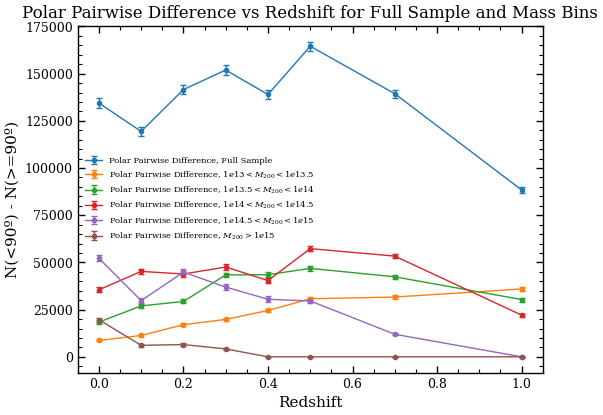

In [13]:
polarPairwiseDifference_plotter = AstroPlotter()
polarPairwiseDifference_fig, polarPairwiseDifference_ax = polarPairwiseDifference_plotter.create_figure()
polarPairwiseDifference_ax.errorbar(
    redshifts,
    polarDifference_full_sample,
    yerr=polarDifference_full_sample_err,
    label='Polar Pairwise Difference, Full Sample',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
    )
for i in range(len(mass_bin_labels)):
    polarPairwiseDifference_ax.errorbar(
        redshifts,
        polarDifference_mass_bins[i],
        yerr=polarDifference_mass_bins_err[i],
        label=f'Polar Pairwise Difference, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarPairwiseDifference_ax.set_xlabel('Redshift')
polarPairwiseDifference_ax.set_ylabel('N(<90º) - N(>=90º)')
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_ax.legend(fontsize=6)
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_poisson_propagated_TNG300-1


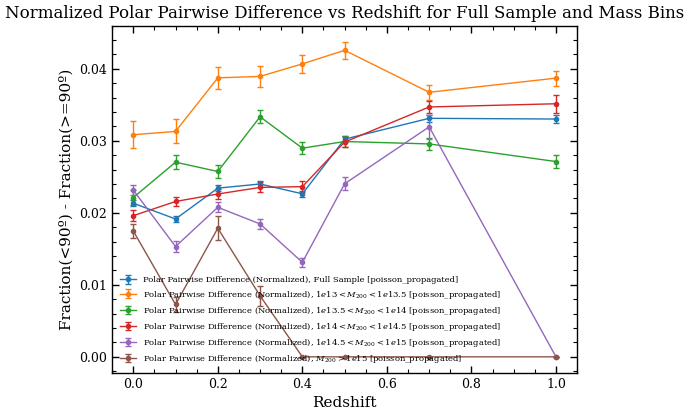

In [14]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
# plot the normalized version of the above (frac(<90º) - frac(>=90º)) vs redshift for the full sample and mass bins
import numpy as np

# Choose error model for d = f_lt - f_ge
# - 'binomial': previous multinomial/binomial approximation
# - 'poisson_propagated': Poisson on <90 and >=90 counts, normalized by N, then propagated
error_model = 'poisson_propagated'  # set to 'binomial' to recover the previous behavior

def frac_diff_and_sigma(frac_lt, frac_ge, n_total, n_lt, n_ge, model='binomial'):
    d = float(frac_lt) - float(frac_ge)
    n = int(n_total)
    if n <= 0:
        return d, 0.0

    if model == 'binomial':
        # Previous formula: Var(d) = (1 - d^2) / N
        sigma = float(np.sqrt(max(0.0, 1.0 - d * d) / n))
        return d, sigma

    if model == 'poisson_propagated':
        # Poisson on counts, then normalize to fractions by N
        sigma_f_lt = np.sqrt(max(float(n_lt), 0.0)) / n
        sigma_f_ge = np.sqrt(max(float(n_ge), 0.0)) / n
        sigma = float(np.sqrt(sigma_f_lt**2 + sigma_f_ge**2))
        return d, sigma

    raise ValueError(f'Unknown error model: {model}')

full_frac_diff = []
full_frac_diff_err = []
for frac_lt, frac_ge, n, n_lt, n_ge in zip(full_frac_lt90, full_frac_ge90, full_total_pairs, full_n_lt90, full_n_ge90):
    d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
    full_frac_diff.append(d)
    full_frac_diff_err.append(s)

mass_frac_diff = [[] for _ in range(len(mass_bin_labels))]
mass_frac_diff_err = [[] for _ in range(len(mass_bin_labels))]
for i in range(len(mass_bin_labels)):
    for frac_lt, frac_ge, n, n_lt, n_ge in zip(
        mass_frac_lt90[i],
        mass_frac_ge90[i],
        mass_total_pairs[i],
        mass_n_lt90[i],
        mass_n_ge90[i],
    ):
        d, s = frac_diff_and_sigma(frac_lt, frac_ge, n, n_lt, n_ge, model=error_model)
        mass_frac_diff[i].append(d)
        mass_frac_diff_err[i].append(s)

polarPairwiseDifferenceNorm_plotter = AstroPlotter()
polarPairwiseDifferenceNorm_fig, polarPairwiseDifferenceNorm_ax = polarPairwiseDifferenceNorm_plotter.create_figure()

polarPairwiseDifferenceNorm_ax.errorbar(
    redshifts,
    full_frac_diff,
    yerr=full_frac_diff_err,
    label=f'Polar Pairwise Difference (Normalized), Full Sample [{error_model}]',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

for i in range(len(mass_bin_labels)):
    polarPairwiseDifferenceNorm_ax.errorbar(
        redshifts,
        mass_frac_diff[i],
        yerr=mass_frac_diff_err[i],
        label=f'Polar Pairwise Difference (Normalized), {mass_bin_labels[i]} [{error_model}]',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

polarPairwiseDifferenceNorm_ax.set_xlabel('Redshift')
polarPairwiseDifferenceNorm_ax.set_ylabel('Fraction(<90º) - Fraction(>=90º)')
polarPairwiseDifferenceNorm_ax.set_title('Normalized Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifferenceNorm_ax.legend(fontsize=6)

polarPairwiseDifferenceNorm_plotter.save_figure(
    polarPairwiseDifferenceNorm_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_{error_model}_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

# joining redshift

In [15]:
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
print(len(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(2).getSatelliteSubhalos()))
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(2).getGroupID())
for subhalo in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(2).getSubhalos():
    print(subhalo.getIdx())
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698)) #19962
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getIdx()) #19962
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getJoiningRedshiftInfo())
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getJoiningRedshift())
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getJoiningRedshiftInfo()[21])
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getJoiningRedshiftInfo()[22])
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupByID(12).getSubhaloByID(61698).getJoiningRedshiftInfo()[20])

386
2
17908
17909
17911
17913
17914
17916
17922
17923
17924
17925
17926
17927
17929
17931
17932
17933
17935
17936
17938
17939
17940
17941
17942
17946
17947
17948
17949
17950
17951
17952
17954
17957
17958
17960
17961
17963
17964
17965
17968
17969
17970
17971
17973
17974
17975
17980
17981
17982
17984
17987
17988
17990
17992
17993
17995
17996
17997
18000
18001
18002
18003
18005
18008
18009
18010
18012
18013
18014
18017
18018
18019
18020
18021
18022
18025
18026
18027
18028
18030
18031
18034
18035
18036
18037
18038
18040
18042
18043
18044
18045
18049
18050
18051
18052
18054
18057
18058
18059
18061
18063
18068
18069
18072
18074
18075
18077
18079
18080
18081
18085
18086
18088
18091
18092
18094
18096
18097
18099
18100
18101
18102
18103
18105
18106
18107
18109
18110
18111
18113
18114
18116
18117
18118
18119
18120
18121
18123
18124
18125
18126
18129
18132
18133
18134
18135
18138
18139
18140
18141
18142
18144
18145
18146
18147
18149
18150
18152
18153
18154
18155
18156
18157
18159
18161
18162
1816

[np.float64(0.109869940458825), np.float64(0.0239744283827625), np.float64(0.0994018026302219), np.float64(0.0994018026302219), np.float64(0.676110411213478), np.float64(0.950531351585033), np.float64(0.99729422578194), np.float64(0.109869940458825), np.float64(0.598543288187567), np.float64(1.15460271236022), np.float64(1.30237845990597), np.float64(0.0994018026302219), np.float64(0.950531351585033), np.float64(1.24847261424514), np.float64(0.546392183141022), np.float64(0.923000816177909), np.float64(0.0485236299818059), np.float64(0.058507322794513), np.float64(0.0485236299818059), np.float64(0.575980845107887), np.float64(1.30237845990597), np.float64(0.0239744283827625), np.float64(0.598543288187567), np.float64(0.851470900624649), np.float64(0.950531351585033), np.float64(0.503047523244883), np.float64(0.0838844307974793), np.float64(0.886896937575248), np.float64(0.0239744283827625), np.float64(0.676110411213478), np.float64(0.141876203969562), np.float64(1.90408954353277), np.f

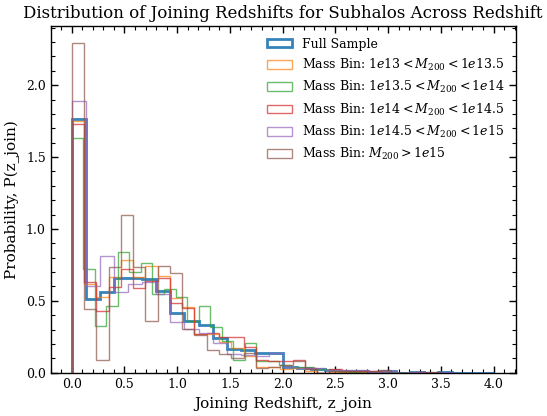

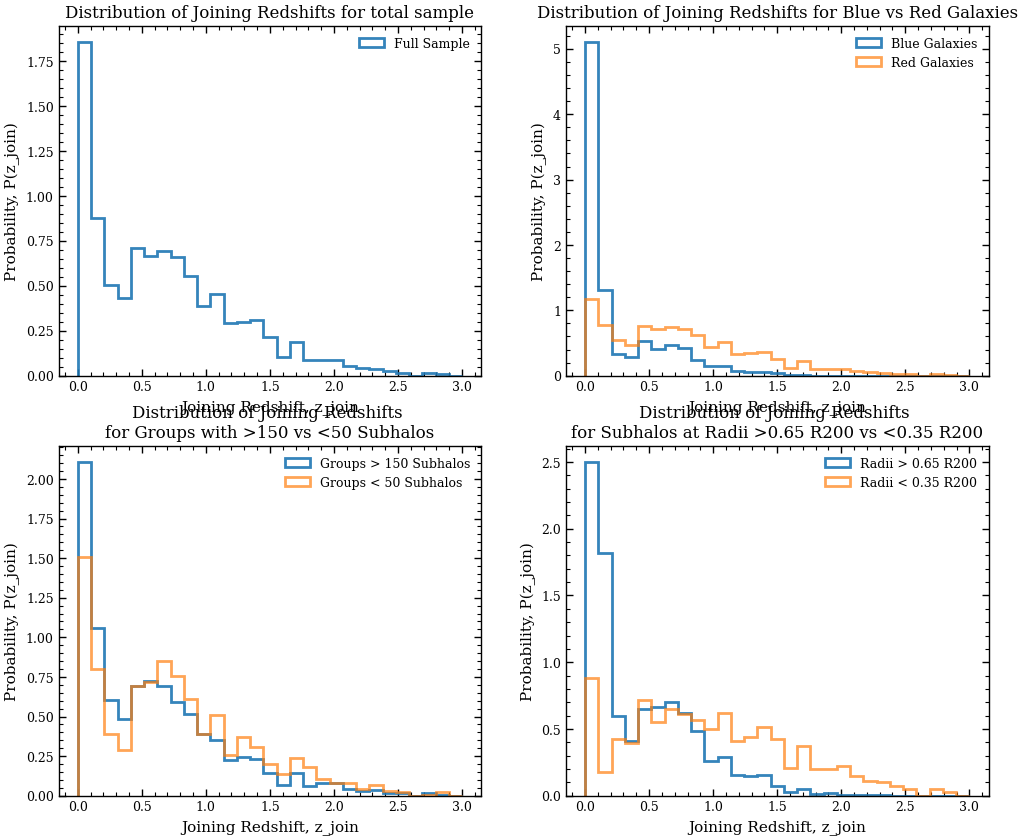

In [16]:
# plot the probability distribution for joining redshift of subhalos, excluding when its np.nan, and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np
redshifts = []
joining_redshift_full_sample = []
joining_redshift_mass_bins = [[] for _ in range(len(mass_bin_labels))]
snapshot = SnapshotEnum.SNAPSHOT_99.value
alphaPrimary = 0.9
alphaSecondary = 0.7
numR200Join = 1

galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
redshifts.append(snapshot[1])

# Full sample: accumulate joining redshifts from all mass bins
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    for subhalo in group.getSatelliteSubhalos():
        # if not np.isnan(subhalo.getJoiningRedshift()):
        joining_redshift_full_sample.append(subhalo.getJoiningRedshift(numR200=numR200Join))

print(joining_redshift_full_sample)

# Mass bins: accumulate joining redshifts separately for each bin
for i, mass_bin in enumerate(mass_bins):
    for group in mass_bin.getAllGalaxyGroups():
        for subhalo in group.getSatelliteSubhalos():
            # if not np.isnan(subhalo.getJoiningRedshift()):
            joining_redshift_mass_bins[i].append(subhalo.getJoiningRedshift(numR200=numR200Join))
# Now plot the distributions of joining redshifts for the full sample and mass bins across redshift
joiningRedshift_plotter = AstroPlotter()
joiningRedshift_fig, joiningRedshift_ax = joiningRedshift_plotter.create_figure()
joiningRedshift_ax.hist(joining_redshift_full_sample, bins=30, alpha=alphaPrimary, label='Full Sample', histtype='step', density=True, linewidth=2)
for i in range(len(mass_bin_labels)):
    joiningRedshift_ax.hist(joining_redshift_mass_bins[i], bins=30, alpha=alphaSecondary, label=f'Mass Bin: {mass_bin_labels[i]}', histtype='step', density=True, linewidth=1)
joiningRedshift_ax.set_xlabel('Joining Redshift, z_join')
joiningRedshift_ax.set_ylabel('Probability, P(z_join)')
joiningRedshift_ax.set_title('Distribution of Joining Redshifts for Subhalos Across Redshift')
joiningRedshift_ax.legend()








#do same but separate for blue/red galaxys, group number > or < 150 or 50, and radius > 0.65R200 or < 0.35R200
joining_redshift_blue = []
joining_redshift_red = []
joining_redshift_group_gt150 = []
joining_redshift_group_lt50 = []
joining_redshift_radius_gt065 = []
joining_redshift_radius_lt035 = []

# for mass_bin in mass_bins:
#     for group in mass_bin.getAllGalaxyGroups():
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift()):
            joiningRedshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            if abs(subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()) < 0.65:
                joining_redshift_blue.append(joiningRedshift)
            else:
                joining_redshift_red.append(joiningRedshift)
            if len(group.getSatelliteSubhalos()) > 150:
                joining_redshift_group_gt150.append(joiningRedshift)
            elif len(group.getSatelliteSubhalos()) < 50:
                joining_redshift_group_lt50.append(joiningRedshift)
            if subhalo.getDistanceToGroupCenter() > 0.65 * group.getRCrit200():
                joining_redshift_radius_gt065.append(joiningRedshift)
            elif subhalo.getDistanceToGroupCenter() < 0.35 * group.getRCrit200():
                joining_redshift_radius_lt035.append(joiningRedshift)
                        
joiningRedshift_split_plotter = AstroPlotter()
joiningRedshift_split_fig, joiningRedshift_split_ax = joiningRedshift_split_plotter.create_figure(nrows=2, ncols=2, figsize=(12, 10))
bins_primary = np.linspace(0, 3, 30)
bins_secondary = np.linspace(0, 3, 30)
linewidthConst = 2

joiningRedshift_split_ax[0, 0].hist(joining_redshift_full_sample, bins=bins_primary, alpha=alphaPrimary, label='Full Sample', histtype='step', density=True, linewidth=linewidthConst)
joiningRedshift_split_ax[0, 1].hist(joining_redshift_blue, bins=bins_primary, alpha=alphaPrimary, label='Blue Galaxies', histtype='step', density=True, linewidth=linewidthConst)
joiningRedshift_split_ax[0, 1].hist(joining_redshift_red, bins=bins_secondary, alpha=alphaSecondary, label='Red Galaxies', histtype='step', density=True, linewidth=linewidthConst)

joiningRedshift_split_ax[1,0].hist(joining_redshift_group_gt150, bins=bins_primary, alpha=alphaPrimary, label='Groups > 150 Subhalos', histtype='step', density=True, linewidth=linewidthConst)
joiningRedshift_split_ax[1,0].hist(joining_redshift_group_lt50, bins=bins_secondary, alpha=alphaSecondary, label='Groups < 50 Subhalos', histtype='step', density=True, linewidth=linewidthConst)

joiningRedshift_split_ax[1,1].hist(joining_redshift_radius_gt065, bins=bins_primary, alpha=alphaPrimary, label='Radii > 0.65 R200', histtype='step', density=True, linewidth=linewidthConst)
joiningRedshift_split_ax[1,1].hist(joining_redshift_radius_lt035, bins=bins_secondary, alpha=alphaSecondary, label='Radii < 0.35 R200', histtype='step', density=True, linewidth=linewidthConst)

joiningRedshift_split_ax[0,  0].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[0,  0].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[0,  0].set_title('Distribution of Joining Redshifts for total sample')
joiningRedshift_split_ax[0,  0].legend()
joiningRedshift_split_ax[0,  1].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[0,  1].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[0, 1].set_title('Distribution of Joining Redshifts for Blue vs Red Galaxies')
joiningRedshift_split_ax[0, 1].legend()
joiningRedshift_split_ax[1,  0].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[1,  0].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[1,  0].set_title('Distribution of Joining Redshifts \nfor Groups with >150 vs <50 Subhalos')
joiningRedshift_split_ax[1,  0].legend()
joiningRedshift_split_ax[1,  1].set_xlabel('Joining Redshift, z_join')
joiningRedshift_split_ax[1,  1].set_ylabel('Probability, P(z_join)')
joiningRedshift_split_ax[1,  1].set_title('Distribution of Joining Redshifts \nfor Subhalos at Radii >0.65 R200 vs <0.35 R200')
joiningRedshift_split_ax[1,  1].legend()
# joiningRedshift_split_plotter.save_figure(
#     joiningRedshift_split_fig,
#     galaxyAnalysisSnapshot.scratchPlotDirc
#     + f'/joining_redshift_distribution_split_by_color_group_size_radius_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
# )

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/fraction_joining_together_vs_redshift_for_full_sample_and_mass_bins_TNG300-1


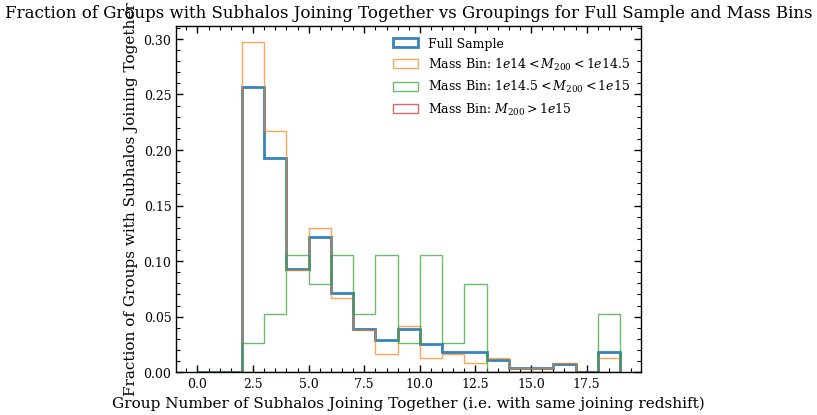

In [17]:
#plot the fraction of galaxies in which have the subhalos in the same group have the same joining redshift (i.e. they joined together) for each grouping number of same joining redshift for the full sample and mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

numR200Join = 1

snapshot = SnapshotEnum.SNAPSHOT_99.value
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
mass_bins = [
    galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
    galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
]
dic_all_groups_joining_redshifts : dict[int, dict[float, list[int]]] = {} # key: groupID, value: dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group
dic_mass_groups_joining_redshifts : dict[str, dict[int, dict[float, list[int]]]] = {} # key: mass bin label, value: dict where key is groupID and value is dict where key is joining redshift and value is list of subhalo IDs with that joining redshift in that group
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    dic_group_joining_redshifts : dict[float, list[int]] = {} # key: joining redshift, value: list of subhalo IDs with that joining redshift
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift()):
            joining_redshift = subhalo.getJoiningRedshift(numR200=numR200Join)
            if joining_redshift not in dic_group_joining_redshifts:
                dic_group_joining_redshifts[joining_redshift] = []
            dic_group_joining_redshifts[joining_redshift].append(subhalo.getIdx())
            
    dic_all_groups_joining_redshifts[group.getGroupID()] = dic_group_joining_redshifts
    if group.getMCrit200() > 1e13 and group.getMCrit200() < 10**13.5:
        mass_bin_label = mass_bin_labels[0]
    elif group.getMCrit200() > 10**13.5 and group.getMCrit200() < 1e14:
        mass_bin_label = mass_bin_labels[1]
    elif group.getMCrit200() > 1e14 and group.getMCrit200() < 10**14.5:
        mass_bin_label = mass_bin_labels[2]
    elif group.getMCrit200() > 10**14.5 and group.getMCrit200() < 1e15:
        mass_bin_label = mass_bin_labels[3]
    elif group.getMCrit200() > 1e15:
        mass_bin_label = mass_bin_labels[4]
    else:
        continue # skip groups that don't fall into any mass bin (shouldn't be any)
    if mass_bin_label not in dic_mass_groups_joining_redshifts:
        dic_mass_groups_joining_redshifts[mass_bin_label] = {}
    dic_mass_groups_joining_redshifts[mass_bin_label][group.getGroupID()] = dic_group_joining_redshifts

groupIDs_full_sample_joining_together = []
for groupID, joining_redshift_dict in dic_all_groups_joining_redshifts.items():
    for joining_redshift, subhaloIDs in joining_redshift_dict.items():
        if len(subhaloIDs) > 1:
            groupIDs_full_sample_joining_together.append(len(subhaloIDs))
            break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
        
bins = np.arange(0, 20, 1) # bins for number of subhalos joining together (i.e. with same joining redshift)


joiningTogether_plotter = AstroPlotter()
joiningTogether_fig, joiningTogether_ax = joiningTogether_plotter.create_figure()
joiningTogether_ax.hist(
    groupIDs_full_sample_joining_together,
    bins=bins,
    alpha=alphaPrimary,
    label='Full Sample',
    histtype='step',
    weights=np.ones_like(groupIDs_full_sample_joining_together) / len(groupIDs_full_sample_joining_together), # normalize to fraction of groups
    linewidth=2
)

groupIDs_mass_bins_joining_together : dict[str, list[int]] = {} # key: mass bin label, value: list of number of subhalos joining together for groups in that mass bin
for mass_bin_label, groups_joining_redshifts in dic_mass_groups_joining_redshifts.items():
    groupIDs_mass_bins_joining_together[mass_bin_label] = []
    for groupID, joining_redshift_dict in groups_joining_redshifts.items():
        for joining_redshift, subhaloIDs in joining_redshift_dict.items():
            if len(subhaloIDs) > 1:
                groupIDs_mass_bins_joining_together[mass_bin_label].append(len(subhaloIDs))
                break # only need to count each group once, so break after finding the first joining redshift with >1 subhalo
for i in range(len(mass_bin_labels)):
    if mass_bin_labels[i] in groupIDs_mass_bins_joining_together:
        joiningTogether_ax.hist(
            groupIDs_mass_bins_joining_together[mass_bin_labels[i]],
            bins=bins,
            alpha=alphaSecondary,
            label=f'Mass Bin: {mass_bin_labels[i]}',
            histtype='step',
            weights=np.ones_like(groupIDs_mass_bins_joining_together[mass_bin_labels[i]]) / len(groupIDs_mass_bins_joining_together[mass_bin_labels[i]]),
            linewidth=1
        )
joiningTogether_ax.set_xlabel('Group Number of Subhalos Joining Together (i.e. with same joining redshift)')
joiningTogether_ax.set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_ax.set_title('Fraction of Groups with Subhalos Joining Together vs Groupings for Full Sample and Mass Bins')
joiningTogether_ax.legend()
joiningTogether_plotter.save_figure(
    joiningTogether_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/fraction_joining_together_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)


In [ ]:

#do the same but split by blue/red galaxies, group number > or < 150 or 50, and radius > 0.65R200 or < 0.35R200
joining_together_blue = []
joining_together_red = []
joining_together_group_gt150 = []
joining_together_group_lt50 = []
joining_together_radius_gt065 = []
joining_together_radius_lt035 = []
total_groups_blue = 0
joining_together_count_blue = 0
total_groups_red = 0
joining_together_count_red = 0
total_groups_group_gt150 = 0
joining_together_count_group_gt150 = 0
total_groups_group_lt50 = 0
joining_together_count_group_lt50 = 0
total_groups_radius_gt065 = 0
joining_together_count_radius_gt065 = 0
total_groups_radius_lt035 = 0
joining_together_count_radius_lt035 = 0
for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    joining_redshifts = []
    colors = []
    radii = []
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift()):
            joining_redshifts.append(subhalo.getJoiningRedshift(numR200=numR200Join))
            colors.append('blue' if abs(subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()) < 0.65 else 'red')
            radii.append(subhalo.getDistanceToGroupCenter() / group.getRCrit200())
    if len(joining_redshifts) > 1:
        # Blue vs Red
        if all(c == 'blue' for c in colors):
            total_groups_blue += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_blue += 1
        elif all(c == 'red' for c in colors):
            total_groups_red += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_red += 1
        # Group size
        if len(group.getSatelliteSubhalos()) > 150:
            total_groups_group_gt150 += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_group_gt150 += 1
        elif len(group.getSatelliteSubhalos()) < 50:
            total_groups_group_lt50 += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_group_lt50 += 1
        # Radius
        if all(r > 0.65 for r in radii):
            total_groups_radius_gt065 += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_radius_gt065 += 1
        elif all(r < 0.35 for r in radii):
            total_groups_radius_lt035 += 1
            if len(set(joining_redshifts)) == 1:
                joining_together_count_radius_lt035 += 1
fraction_joining_together_blue = joining_together_count_blue / total_groups_blue if total_groups_blue > 0 else 0.0
fraction_joining_together_red = joining_together_count_red / total_groups_red if total_groups_red > 0 else 0.0
fraction_joining_together_group_gt150 = joining_together_count_group_gt150 / total_groups_group_gt150 if total_groups_group_gt150 > 0 else 0.0
fraction_joining_together_group_lt50 = joining_together_count_group_lt50 / total_groups_group_lt50 if total_groups_group_lt50 > 0 else 0.0
fraction_joining_together_radius_gt065 = joining_together_count_radius_gt065 / total_groups_radius_gt065 if total_groups_radius_gt065 > 0 else 0.0
fraction_joining_together_radius_lt035 = joining_together_count_radius_lt035 / total_groups_radius_lt035 if total_groups_radius_lt035 > 0 else 0.0
joiningTogether_split_plotter = AstroPlotter()
joiningTogether_split_fig, joiningTogether_split_ax = joiningTogether_split_plotter.create_figure(nrows=2, ncols=2, figsize=(12, 10))
joiningTogether_split_ax[0, 0].bar(['Full Sample', 'Blue Galaxies', 'Red Galaxies'], [fraction_joining_together_full_sample[0], fraction_joining_together_blue, fraction_joining_together_red], color=['gray', 'blue', 'red'])
joiningTogether_split_ax[0, 0].set_title('Fraction Joining Together: Full Sample vs Blue vs Red')
joiningTogether_split_ax[0, 0].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[1, 0].bar(['Groups >150 Subhalos', 'Groups <50 Subhalos'], [fraction_joining_together_group_gt150, fraction_joining_together_group_lt50], color=['orange', 'green'])
joiningTogether_split_ax[1, 0].set_title('Fraction Joining Together: Group Size >150 vs <50 Subhalos')
joiningTogether_split_ax[1, 0].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_ax[1, 1].bar(['Radii >0.65 R200', 'Radii <0.35 R200'], [fraction_joining_together_radius_gt065, fraction_joining_together_radius_lt035], color=['purple', 'cyan'])
joiningTogether_split_ax[1, 1].set_title('Fraction Joining Together: Radii >0.65 R200 vs <0.35 R200')
joiningTogether_split_ax[1, 1].set_ylabel('Fraction of Groups with Subhalos Joining Together')
joiningTogether_split_plotter.save_figure(
    joiningTogether_split_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/fraction_joining_together_split_by_color_group_size_radius_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

Processing Subhalo 4/550 in Galaxy Group ID 0 with total pairs 150975

Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606

ValueError: 'x' and 'y' must have the same size

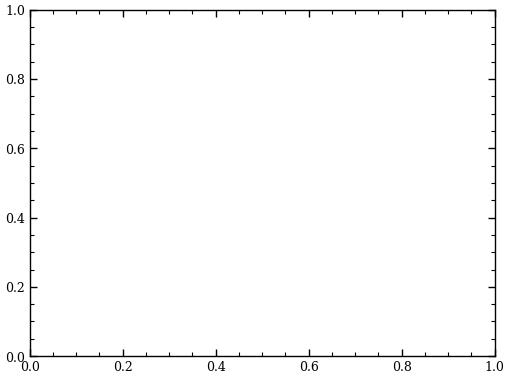

In [19]:
#plot the regular polar pairwise difference but separate between galaxies that joined together vs those that didn't (i.e. have same joining redshift vs different joining redshifts) compared to the full sample. And also separate galaxies with joining redshift < 1.0 vs > 1.0
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
polarDifference_joiningTogether = []
polarDifference_joiningTogether_err = []
polarDifference_notJoiningTogether = []
polarDifference_notJoiningTogether_err = []
polarDifference_joiningRedshiftLt1 = []
polarDifference_joiningRedshiftLt1_err = []
polarDifference_joiningRedshiftGt1 = []
polarDifference_joiningRedshiftGt1_err = []

for group in galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    joining_redshifts = []
    for subhalo in group.getSatelliteSubhalos():
        if not np.isnan(subhalo.getJoiningRedshift()):
            joining_redshifts.append(subhalo.getJoiningRedshift(numR200=numR200Join))
    if len(joining_redshifts) > 1:
        polarRawValues = ListGalaxyGroup._compute_pairwise_for_group(group)
        stats = polar_lt90_ge90_stats_from_hist(polarRawValues, bin_size_deg=5.0)
        if len(set(joining_redshifts)) == 1:
            polarDifference_joiningTogether.append(stats['diff'])
            polarDifference_joiningTogether_err.append(stats['sigma_poisson'])
        else:
            polarDifference_notJoiningTogether.append(stats['diff'])
            polarDifference_notJoiningTogether_err.append(stats['sigma_poisson'])
        if all(j < 1.0 for j in joining_redshifts):
            polarDifference_joiningRedshiftLt1.append(stats['diff'])
            polarDifference_joiningRedshiftLt1_err.append(stats['sigma_poisson'])
        elif all(j >= 1.0 for j in joining_redshifts):
            polarDifference_joiningRedshiftGt1.append(stats['diff'])
            polarDifference_joiningRedshiftGt1_err.append(stats['sigma_poisson'])
polarDifference_joiningTogether_plotter = AstroPlotter()
polarDifference_joiningTogether_fig, polarDifference_joiningTogether_ax = polarDifference_joiningTogether_plotter.create_figure()
polarDifference_joiningTogether_ax.errorbar(
    redshifts,
    polarDifference_joiningTogether,
    yerr=polarDifference_joiningTogether_err,
    label='Polar Pairwise Difference, Joining Together',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
polarDifference_joiningTogether_ax.errorbar(
    redshifts,
    polarDifference_notJoiningTogether,
    yerr=polarDifference_notJoiningTogether_err,
    label='Polar Pairwise Difference, Not Joining Together',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
polarDifference_joiningTogether_ax.errorbar(
    redshifts,
    polarDifference_joiningRedshiftLt1,
    yerr=polarDifference_joiningRedshiftLt1_err,
    label='Polar Pairwise Difference, Joining Redshift < 1.0',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
polarDifference_joiningTogether_ax.errorbar(
    redshifts,
    polarDifference_joiningRedshiftGt1,
    yerr=polarDifference_joiningRedshiftGt1_err,
    label='Polar Pairwise Difference, Joining Redshift >= 1.0',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
polarDifference_joiningTogether_ax.set_xlabel('Redshift')
polarDifference_joiningTogether_ax.set_ylabel('N(<90º) - N(>=90º)')
polarDifference_joiningTogether_ax.set_title('Polar Pairwise Difference vs Redshift for Joining Together vs Not Joining Together vs Joining Redshift <1 vs >=1')
polarDifference_joiningTogether_ax.legend(fontsize=6)
polarDifference_joiningTogether_plotter.save_figure(
    polarDifference_joiningTogether_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_joining_together_vs_not_joining_together_and_joining_redshift_lt1_vs_ge1_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)


# what is driving the lopsidedness

total to process: 280
Number of galaxy groups with satellites within 35% R200: 280
total to process: 280
Number of galaxy groups with satellites within 65-100% R200: 280
final: [np.float64(0.10022396175429021), np.float64(0.09242871292714062), np.float64(0.10527981053593036)]
Fraction of MRL values below the 99.0th percentile of random MRL values: 0.9762 (820/840)ss
lenMRL: 840, lenrandom: (280, 3000)
99th percentile MRL: 0.534170563865886
Overall number of MRL values above 99th percentile: 12 out of 840
final: [np.float64(0.13533119120623335), np.float64(0.1513366992045873), np.float64(0.22535705838375586)]
Fraction of MRL values below the 99.0th percentile of random MRL values: 0.8821 (741/840)ss
lenMRL: 840, lenrandom: (280, 3000)
99th percentile MRL: 0.5104430968629833
Overall number of MRL values above 99th percentile: 50 out of 840


(<myproject.utilities.plottingTools.AstroPlotter at 0x1497dbf6a360>,
 <Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': "MRL Distribution Curves vs Random for TNG300-1, GT\n 65% R200, z=(0, 'z0p0'), TNG300-1"}, xlabel='MRL Directionality', ylabel='Probability Density'>)

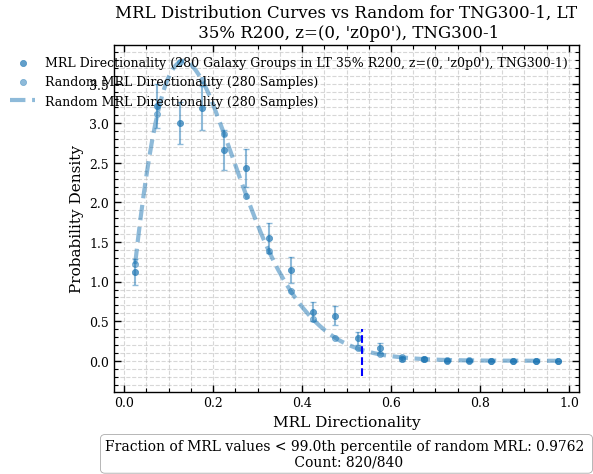

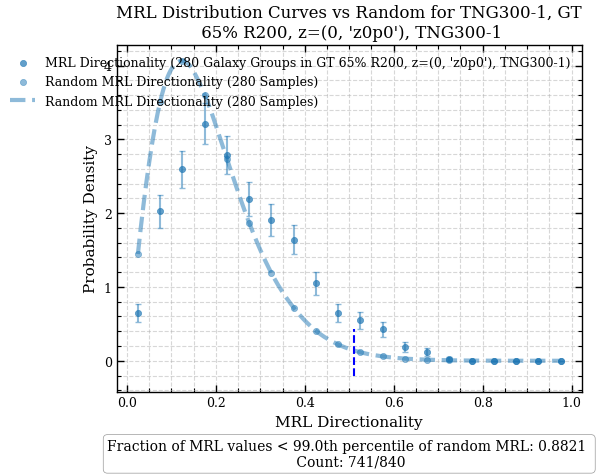

In [12]:
# See if lopsidedness in polar pairwise is being really driven by just a few (which we won't see in mrl since its cluster by cluster).
# i.e. based on fraaction of r200, also plot MRL with this distinction
snapsot=99
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
filtered_LT35R200_list_of_galaxy_groups = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0,0.35])
print(f'Number of galaxy groups with satellites within 35% R200: {filtered_LT35R200_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_GT65R200_list_of_galaxy_groups = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0.65,1.00])
print(f'Number of galaxy groups with satellites within 65-100% R200: {filtered_GT65R200_list_of_galaxy_groups.getNumGalaxyGroups()}')

galaxyAnalysisSnapshot.overlayMRLAndMRLRandom([[filtered_LT35R200_list_of_galaxy_groups, f'LT 35% R200, z={galaxyAnalysisSnapshot.snapshot_dic[galaxyAnalysisSnapshot.snapshot]}, TNG300-1']], filename='mrl_difference_lt35r200', oneaxis=True, savefig=False)

galaxyAnalysisSnapshot.overlayMRLAndMRLRandom([[filtered_GT65R200_list_of_galaxy_groups, f'GT 65% R200, z={galaxyAnalysisSnapshot.snapshot_dic[galaxyAnalysisSnapshot.snapshot]}, TNG300-1']], filename='mrl_difference_gt65r200', oneaxis=True, savefig=False)

In [24]:
#get the subhalos which are inconsistent with random
galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(99)
random_MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000) # 1000 samples for each subhalo, for the three different projection angles #i.e. total of 3000 random MRL values for each subhalo, for the three different projection angles
MRL_values = galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False) #three MRL values for each subhalo, for the three different projection angles


final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]


In [25]:
(fraction, count, total, gg_indices_inconsistent) = galaxyAnalysisSnapshot.calculate_fraction_less_than_percentile(MRL_values=MRL_values, random_MRL_values=random_MRL_values, percentile=99)
print(len(gg_indices), gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())

263 [0, 1, 2, 3, 4, 6, 12, 17, 20, 23, 27, 29, 30, 40, 54, 58, 62, 64, 69, 77, 79, 83, 85, 87, 92, 96, 98, 101, 102, 103, 106, 107, 108, 126, 130, 132, 135, 136, 140, 145, 148, 158, 174, 176, 178, 186, 197, 204, 210, 216, 217, 225, 226, 227, 229, 232, 236, 239, 244, 256, 261, 263, 270, 276, 277, 278]
280


In [26]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
print(gg_indices_inconsistent)
print(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups())
#see what are the properties of the gg which are inconsistent with random at 99 percentile, and see if they have any common properties among their subhalos which might be driving the lopsidedness in the polar pairwise distribution, and also see if they have any common properties among themselves (e.g. mass, redshift, number of subhalos, etc.)
high_galaxy_groups = []
non_high_galaxy_groups = []
for i, gg in enumerate(galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups()):
    if i not in gg_indices_inconsistent:
        print(f'Galaxy Group {i} is consistent with random at 99 percentile')
        non_high_galaxy_groups.append(gg)
        continue
    high_galaxy_groups.append(gg)
    print(f'Galaxy Group ID: {gg.getGroupID()}, M200: {gg.getMCrit200():.4e}, Number of Subhalos: {len(gg.getSubhalos())}')
    for subhalo in gg.getSubhalos():
        print(f'  Subhalo ID: {subhalo.getIdx()}, Distance to Group Center: {subhalo.getDistanceToGroupCenter()}, compared to R200: {subhalo.getDistanceToGroupCenter() / gg.getRCrit200()} Joining Redshift: {subhalo.getJoiningRedshift()}, G-R Color: {subhalo.getGbandMagnitude() - subhalo.getRbandMagnitude()}')

[0, 1, 2, 3, 4, 6, 12, 17, 20, 23, 27, 29, 30, 40, 54, 58, 62, 64, 69, 77, 79, 83, 85, 87, 92, 96, 98, 101, 102, 103, 106, 107, 108, 126, 130, 132, 135, 136, 140, 145, 148, 158, 174, 176, 178, 186, 197, 204, 210, 216, 217, 225, 226, 227, 229, 232, 236, 239, 244, 256, 261, 263, 270, 276, 277, 278]
280
Galaxy Group ID: 0, M200: 1.5358e+15, Number of Subhalos: 551
  Subhalo ID: 0, Distance to Group Center: 0.0, compared to R200: 0.0 Joining Redshift: nan, G-R Color: -0.9241142272949219
  Subhalo ID: 2, Distance to Group Center: 1277.7773467294455, compared to R200: 0.525245900889846 Joining Redshift: 0.481832943420951, G-R Color: -0.9008636474609375
  Subhalo ID: 51, Distance to Group Center: 1175.0138457046608, compared to R200: 0.48300371541636505 Joining Redshift: 1.49551216649556, G-R Color: -0.9025707244873047
  Subhalo ID: 265, Distance to Group Center: 563.631556956919, compared to R200: 0.2316875985174807 Joining Redshift: 1.206258080781, G-R Color: -0.8734455108642578
  Subhalo I

COMPUTING FOR redshift index: 0, label: High Galaxy Groups(Inconsistent with Random MRL at 99% CL)
Total Galaxy Groups to process: 66 with pairs : 862629
Processing Subhalo 105/105 in Galaxy Group ID 98 with total pairs 54606COMPUTING FOR redshift index: 0, label: Non-High Galaxy Groups (Consistent with Random MRL at 99% CL)
Total Galaxy Groups to process: 214 with pairs : 891273
Processing Subhalo 54/77 in Galaxy Group ID 106 with total pairs 2926

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)] / 66 with 551 satellites
Fraction of MRL values below the 99.0th percentile of random MRL values: 0.3687 (73/198)s
lenMRL: 198, lenrandom: (66, 30000)
99th percentile MRL: 0.26088811586304766
Overall number of MRL values above 99th percentile: 88 out of 198


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Fraction of MRL values below the 99.0th percentile of random MRL values: 0.9953 (639/642)ss
lenMRL: 642, lenrandom: (214, 30000)
99th percentile MRL: 0.29102153052723106
Overall number of MRL values above 99th percentile: 4 out of 642


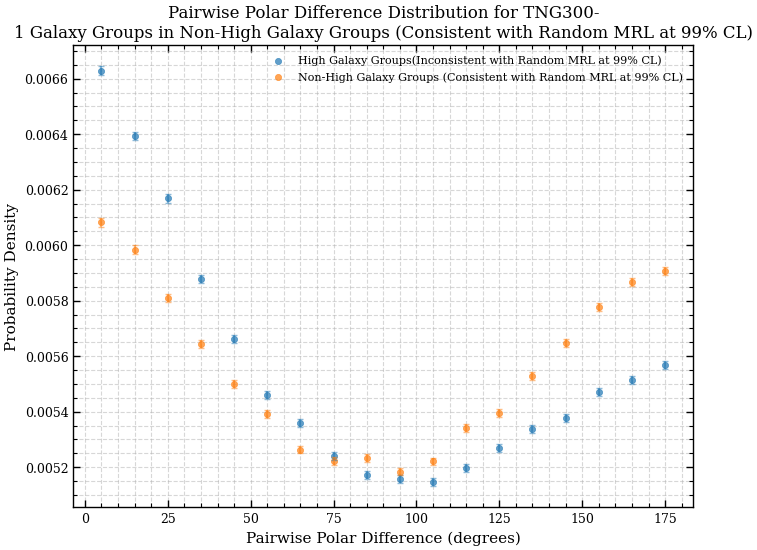

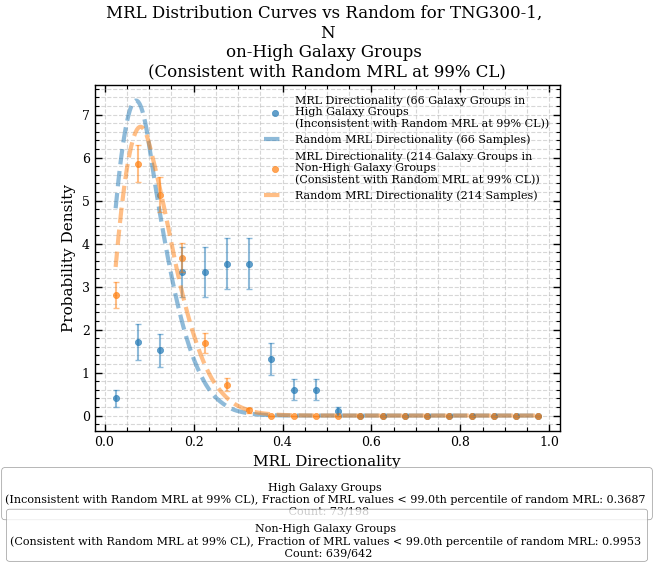

In [27]:
high_list_galaxy_groups = ListGalaxyGroup(high_galaxy_groups)
non_high_list_galaxy_groups = ListGalaxyGroup(non_high_galaxy_groups)

#plot polar pairwise distribution for the high galaxy groups and the non-high galaxy groups, and see if the lopsidedness in the polar pairwise distribution is being really driven by just a few (which we won't see in mrl since its cluster by cluster).
high_nonhigh_polar_plot, high_nonhigh_fig, high_nonhigh_ax = galaxyAnalysisSnapshot.overlay_polar_pairwise_across_redshifts([
    [(high_list_galaxy_groups, "High Galaxy Groups(Inconsistent with Random MRL at 99% CL)"),
    (non_high_list_galaxy_groups, "Non-High Galaxy Groups (Consistent with Random MRL at 99% CL)")]],
    oneaxis=True,
)

high_nonhigh_ax.legend(fontsize=8)


#plot MRL
high_nonhigh_MRL_plot, high_nonhigh_MRL_fig, high_nonhigh_MRL_ax = galaxyAnalysisSnapshot.overlayMRLAndMRLRandom([
    (high_list_galaxy_groups, "\nHigh Galaxy Groups \n(Inconsistent with Random MRL at 99% CL)"),
    (non_high_list_galaxy_groups, "\nNon-High Galaxy Groups \n(Consistent with Random MRL at 99% CL)")],
    filename='mrl_difference_high_nonhigh', oneaxis=True, savefig=False
)